# Customer Segmentation and Review Score Prediction for Olist E-Commerce
### By Brad Wicklund

## 02. Exploritory Data Analysis

Olist is an e-commerce platform that connects small businesses across Brazil with customers nationwide.  
For Olist, customer satisfaction is a critical business driver because higher ratings and repeat purchases strengthen trust and loyalty on the platform.  

The goal of this exploratory data analysis (EDA) is to uncover the underlying patterns in customer orders, payments, delivery times, and reviews. By understanding these relationships, we can identify the pain points that most influence customer satisfaction (e.g., delivery delays, payment complexity, order value) and highlight opportunities for improving customer experience.  

These insights will serve as the foundation for segmentation (RFM analysis + clustering) and for building predictive models that estimate customer satisfaction, enabling Olist to design data-driven strategies that increase retention and lifetime value.

## A. Setup Notebook

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load data
customers = pd.read_csv('../data/processed/customers_clean.csv')
order_items = pd.read_csv('../data/processed/order_items_clean.csv')
order_payments = pd.read_csv('../data/processed/order_payments_clean.csv')
order_reviews = pd.read_csv('../data/processed/order_reviews_clean.csv')
orders = pd.read_csv('../data/processed/orders_clean.csv')
products = pd.read_csv('../data/processed/products_clean.csv')
sellers = pd.read_csv('../data/processed/sellers_clean.csv')

## B. Data Overview

In [5]:
# Create dictionary of all dataframes
tables = {
    "customers": customers,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
}

# Loop through and print shape and columns
for name, df in tables.items():
    print(f"--- {name.upper()} ---")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
    print(f"Columns: {df.columns.tolist()}")
    print()

--- CUSTOMERS ---
Shape: 99,441 rows × 5 columns
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

--- ORDER_ITEMS ---
Shape: 112,650 rows × 7 columns
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

--- ORDER_PAYMENTS ---
Shape: 103,886 rows × 5 columns
Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

--- ORDER_REVIEWS ---
Shape: 99,224 rows × 7 columns
Columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

--- ORDERS ---
Shape: 99,441 rows × 8 columns
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

--- PRODUCTS ---
Shape: 32,327 rows × 10 columns
Columns: ['pr

In [6]:
# Loop and show .info() for each
for name, df in tables.items():
    print(f"\n--- {name.upper()} ---")
    df.info()


--- CUSTOMERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

--- ORDER_ITEMS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shi

In [7]:
# Convert dtypes

# CUSTOMERS
customers['customer_id'] = customers['customer_id'].astype('category')
customers['customer_unique_id'] = customers['customer_unique_id'].astype('category')
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype(str)  # keep as text
customers['customer_city'] = customers['customer_city'].astype('category')
customers['customer_state'] = customers['customer_state'].astype('category')

# ORDER_ITEMS
order_items['order_id'] = order_items['order_id'].astype('category')
order_items['product_id'] = order_items['product_id'].astype('category')
order_items['seller_id'] = order_items['seller_id'].astype('category')
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

# ORDER_PAYMENTS
order_payments['order_id'] = order_payments['order_id'].astype('category')
order_payments['payment_type'] = order_payments['payment_type'].astype('category')

# ORDER_REVIEWS
order_reviews['review_id'] = order_reviews['review_id'].astype('category')
order_reviews['order_id'] = order_reviews['order_id'].astype('category')
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

# ORDERS
orders['order_id'] = orders['order_id'].astype('category')
orders['customer_id'] = orders['customer_id'].astype('category')
orders['order_status'] = orders['order_status'].astype('category')
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# PRODUCTS
products['product_id'] = products['product_id'].astype('category')
products['product_category_name'] = products['product_category_name'].astype('category')
products['product_category_name_english'] = products['product_category_name_english'].astype('category')

# SELLERS
sellers['seller_id'] = sellers['seller_id'].astype('category')
sellers['seller_zip_code_prefix'] = sellers['seller_zip_code_prefix'].astype(str)  # keep as text
sellers['seller_city'] = sellers['seller_city'].astype('category')
sellers['seller_state'] = sellers['seller_state'].astype('category')

In [8]:
# Loop and show .nunique() for each
for name, df in tables.items():
    print(f"\n--- {name.upper()} ---")
    print(df.nunique())


--- CUSTOMERS ---
customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

--- ORDER_ITEMS ---
order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

--- ORDER_PAYMENTS ---
order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64

--- ORDER_REVIEWS ---
review_id                  98410
order_id                   98673
review_score                   5
review_comment_title        4528
review_comment_message     36160
review_creation_date         636
review_answer_timestamp    98248
dtype: int64

--- ORDERS ---
order_id                         99441
customer_id                      99441
order_status 

In [9]:
# Loop and show missing values for each
for name, df in tables.items():
    print(f"\n--- {name.upper()} ---")
    mv = df.isnull().sum()
    mv = mv[mv > 0].sort_values(ascending=False)
    mv_percent = (mv / len(df)) * 100
    print(pd.DataFrame({
        "Missing Values": mv,
        "Percent": mv_percent.round(2)
    }))


--- CUSTOMERS ---
Empty DataFrame
Columns: [Missing Values, Percent]
Index: []

--- ORDER_ITEMS ---
Empty DataFrame
Columns: [Missing Values, Percent]
Index: []

--- ORDER_PAYMENTS ---
Empty DataFrame
Columns: [Missing Values, Percent]
Index: []

--- ORDER_REVIEWS ---
Empty DataFrame
Columns: [Missing Values, Percent]
Index: []

--- ORDERS ---
                               Missing Values  Percent
order_delivered_customer_date            2965     2.98
order_delivered_carrier_date             1783     1.79
order_approved_at                         160     0.16

--- PRODUCTS ---
Empty DataFrame
Columns: [Missing Values, Percent]
Index: []

--- SELLERS ---
Empty DataFrame
Columns: [Missing Values, Percent]
Index: []


In [10]:
# Loop and show .duplicated() for each
for name, df in tables.items():
    dup_count = df.duplicated().sum()
    print(f"{name.upper():<15} Duplicate Rows: {dup_count}")

CUSTOMERS       Duplicate Rows: 0
ORDER_ITEMS     Duplicate Rows: 0
ORDER_PAYMENTS  Duplicate Rows: 0
ORDER_REVIEWS   Duplicate Rows: 0
ORDERS          Duplicate Rows: 0
PRODUCTS        Duplicate Rows: 0
SELLERS         Duplicate Rows: 0


In [12]:
# Loop and show describe() for each
for name, df in tables.items():
    print(f"\n--- {name.upper()} ---\n")
    print(df.describe())


--- CUSTOMERS ---

                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     00012a2ce6f8dcda20d059ce98491703  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   

       customer_zip_code_prefix customer_city customer_state  
count                     99441         99441          99441  
unique                    14994          4119             27  
top                       22790     sao paulo             SP  
freq                        142         15540          41746  

--- ORDER_ITEMS ---

       order_item_id            shipping_limit_date          price  \
count  112650.000000                         112650  112650.000000   
mean        1.197834  2018-01-07 15:36:52.192685312     120.653739   
min         1.000000            2016-09-19

### Data Overview Insights

i. Customers
High geographic concentration in SP could be useful for shipping analysis

ii. Orders
Outliers in price and freight may be luxury or oversized items.  May need to use log-scaling for modeling.

iii. Order Payments
A few high value orders may distort averages.

iv. Order Reviews
Very low number of negative reviews.

v. Orders
Delivery delays likely affect review scores.

vi. Products
Outliers in weight and width may need review.

vii. Sellers
Seller location could be mapped against delivery times.

## C. Univariate Analysis

### i. Numerical Values

#### Price Analysis

In [20]:
# Describe Price
order_items['price'].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

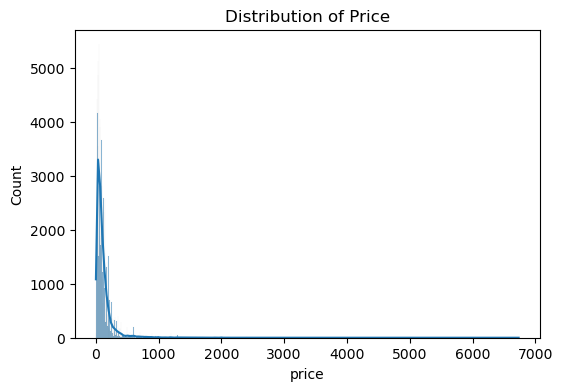

In [21]:
# Histogram and KDE of price
plt.figure(figsize=(6,4))
sns.histplot(order_items['price'], kde=True)
plt.title('Distribution of Price')
plt.show()

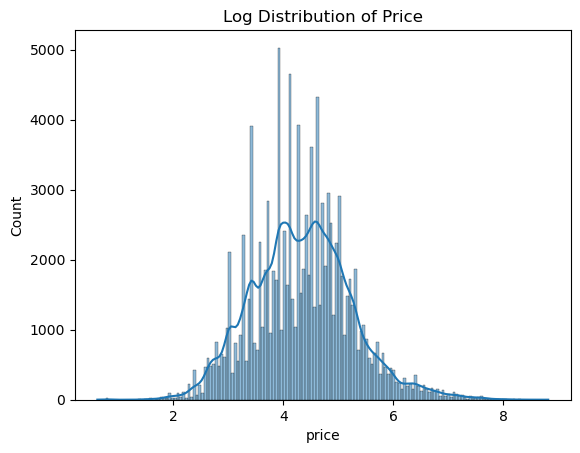

In [25]:
# Histogram and KDE of log of price
sns.histplot(np.log1p(order_items['price']), kde=True)
plt.title('Log Distribution of Price')
plt.show()

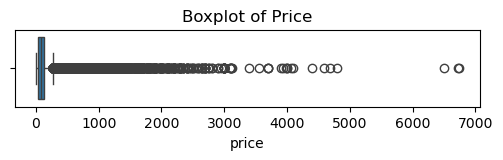

In [28]:
# Boxplot of price
plt.figure(figsize=(6,1))
sns.boxplot(x=order_items['price'])
plt.title('Boxplot of Price')
plt.show()

In [30]:
# Check skewness
order_items['price'].skew()

7.92320826321351

In [31]:
# Check outlier thresholds
Q1 = order_items['price'].quantile(0.25)
Q3 = order_items['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = order_items[
    (order_items['price'] < lower_bound) | 
    (order_items['price'] > upper_bound)
]

print(f"Outliers found: {outliers.shape[0]} ({outliers.shape[0] / len(order_items) * 100:.2f}%)")
outliers['price'].describe()

Outliers found: 8427 (7.48%)


count    8427.000000
mean      574.291188
std       431.196659
min       277.450000
25%       329.000000
50%       409.990000
75%       649.000000
max      6735.000000
Name: price, dtype: float64

In [32]:
# Check price for negative values
(order_items['price'] < 0).sum()

0

##### Price Takeaways
1. **Price distribution is highly skewed with a skewness of 7.92.**
   - Most prices are concentrated around **R\$200** with a max value of **R\$6735**.
   - Using a log transformations produces a  bell-shaped distribution.
<br>
<br>
2. **Central tendency and spread**
   - Median value is **R\$74.99** showing the typical order is inexpensive.
   - Mean  value is **R\$120.65** which is higher than the median due to outliers.
   - Std Dev is **R\$183.63** which is large due to outliers.
<br>
<br>
3. **Outliers are substantial but not errors**
   - IQR method flagged 8427 outliers.
   - Outliers start at **~R\$277** and go up to **R\$6735**.
   - Outliers have a mean price of **R\$574**.
   - There are no negative prices.
<br>
<br>
4. **Practical considerations**
   - The skew would heavily influence linear regression and a log transformation should be used first.
   - The outliers appear to represent luxury items.  This could be treated as a separate segment.
   - Skewed results will need to be considered when creating visualizations to avoid losing key insights.   

#### Freight Value Analysis

In [36]:
# Describe freight value
order_items['freight_value'].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

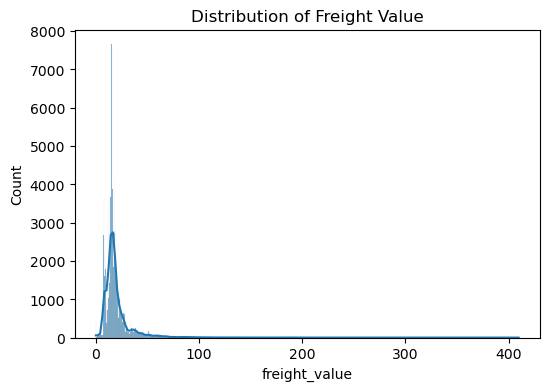

In [40]:
# Histogram and KDE of freight value
plt.figure(figsize=(6,4))
sns.histplot(order_items['freight_value'], kde=True)
plt.title('Distribution of Freight Value')
plt.show()

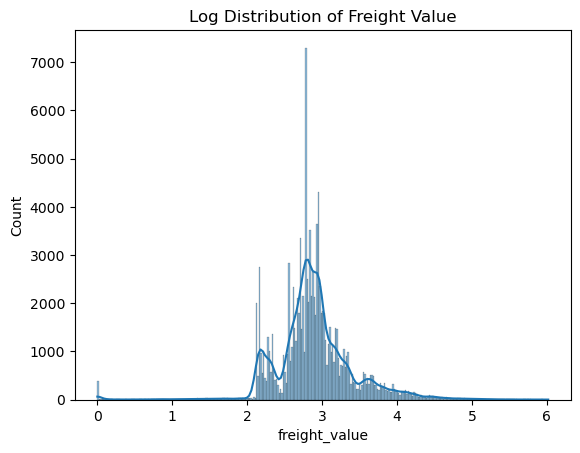

In [44]:
# Histogram and KDE of log of freight value
sns.histplot(np.log1p(order_items['freight_value']), kde=True)
plt.title('Log Distribution of Freight Value')
plt.show()

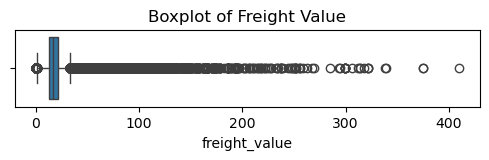

In [45]:
# Boxplot of freight value
plt.figure(figsize=(6,1))
sns.boxplot(x=order_items['freight_value'])
plt.title('Boxplot of Freight Value')
plt.show()

In [46]:
# Check skewness
order_items['freight_value'].skew()

5.639869620428684

In [48]:
# Check outlier thresholds
Q1 = order_items['freight_value'].quantile(0.25)
Q3 = order_items['freight_value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = order_items[
    (order_items['freight_value'] < lower_bound) | 
    (order_items['freight_value'] > upper_bound)
]

print(f"Outliers found: {outliers.shape[0]} ({outliers.shape[0] / len(order_items) * 100:.2f}%)")
outliers['freight_value'].describe()

Outliers found: 12134 (10.77%)


count    12134.000000
mean        52.004304
std         30.384303
min          0.000000
25%         37.100000
50%         44.040000
75%         58.900000
max        409.680000
Name: freight_value, dtype: float64

In [49]:
# Check for zero freight values
zero_freight_count = (order_items['freight_value'] == 0).sum()
zero_freight_pct = zero_freight_count / len(order_items) * 100
print(f"Zero freight values: {zero_freight_count} ({zero_freight_pct:.2f}%)")

Zero freight values: 383 (0.34%)


##### Freight Value Takeaways
1. **Strong positive skew**
   - Skewness = 5.64.
   - A small number of orders have a high freight cost.
<br>
<br>
2. **Outliers are significant, but not necessarily errors**
   - 10.77% are outliers
   - This could be due to distant  deliveries, heavy items, or premium shipping
<br>
<br>
3. **Central tendency is moderate**
   - Median freight values is **R\$16.26**, mean is **R\$19.99**.  This shows the skew is pulling up the mean
   - 74% of freight values are less than or equal to **R\$21.15**, which shows most customers pay low shipping costs.
<br>
<br>
4. **Zero Freight Values**
   - The minimum freight values is 0. This could be due to shipping promotion or data entry issues.
<br>
<br>
5. **Log transformation helps normalization**
   - The log distribution plot show a much more symmetical curve.  This will be useful for modeling if freight becomes a predictor or target variable
<br>
<br>
6. **Business implications**
   - Freight charges are low for the majority but spike for a small subset of orders
   - These spikes could be tied to regions, product types, or service levels and need further review.

#### Payment Value Analysis

In [57]:
# Describe payment value
order_payments['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

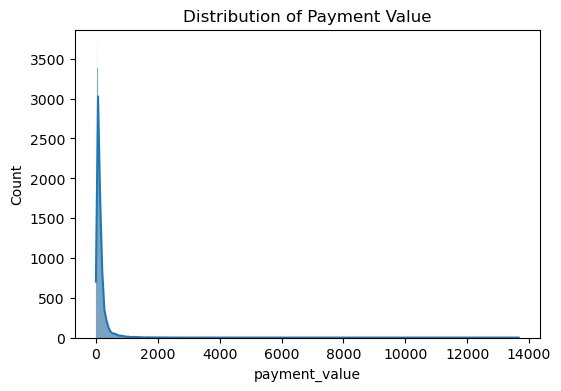

In [59]:
# Histogram and KDE of payment value
plt.figure(figsize=(6,4))
sns.histplot(order_payments['payment_value'], kde=True)
plt.title('Distribution of Payment Value')
plt.show()

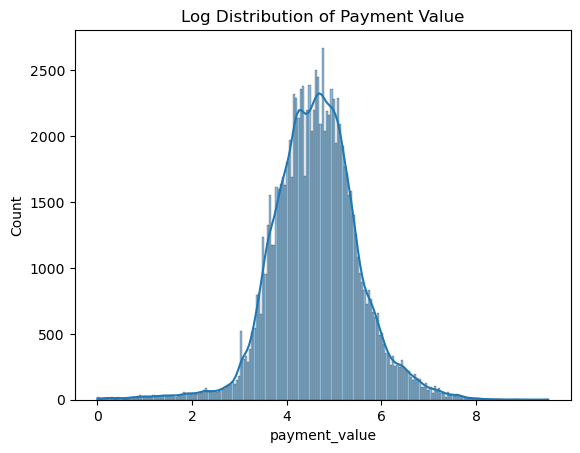

In [60]:
# Histogram and KDE of log of payment value
sns.histplot(np.log1p(order_payments['payment_value']), kde=True)
plt.title('Log Distribution of Payment Value')
plt.show()

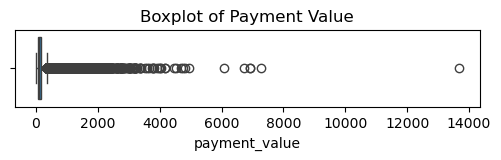

In [61]:
# Boxplot of payment value
plt.figure(figsize=(6,1))
sns.boxplot(x=order_payments['payment_value'])
plt.title('Boxplot of Payment Value')
plt.show()

In [62]:
# Check skewness
order_payments['payment_value'].skew()

9.254009528478063

In [63]:
# Check outlier thresholds
Q1 = order_payments['payment_value'].quantile(0.25)
Q3 = order_payments['payment_value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = order_payments[
    (order_payments['payment_value'] < lower_bound) | 
    (order_payments['payment_value'] > upper_bound)
]

print(f"Outliers found: {outliers.shape[0]} ({outliers.shape[0] / len(order_items) * 100:.2f}%)")
outliers['payment_value'].describe()

Outliers found: 7981 (7.08%)


count     7981.000000
mean       683.293223
std        498.750279
min        344.440000
25%        404.880000
50%        519.930000
75%        761.820000
max      13664.080000
Name: payment_value, dtype: float64

In [64]:
# Check for zero payment values
zero_payment_count = (order_payments['payment_value'] == 0).sum()
zero_payment_pct = zero_payment_count / len(order_payments) * 100
print(f"Zero payment values: {zero_payment_count} ({zero_payment_pct:.2f}%)")

Zero payment values: 9 (0.01%)


##### Payment Value Takeaways
1. **Strong right skew with extreme values**
   - Skewness = 9.25, even higher than price and freight.
   - Histogram shows most payments concentrated at lower values, but a long tail stretches up to **R\$13,664**.
   - Log transformation produces a much more symmetric, bell-like distribution, making it more suitable for modeling.
<br>
<br>
2. **Central tendency and spread**
   - Median = **R\$100**, Mean = **R\$154** Again, this shows the skew is pulling the mean upward.
   - 75% of payments are less than or equal to **R\$172**, so most orders are relatively modest.
   - Standard deviation = 217.5, reflecting large variability.
<br>
<br>
3. **Outliers are numerous but represent large payments**
   - Outliers flagged: 7,981 orders (7.08%).
   - These outliers are not trivial as the median = **R\$520** and mean = **R\$683**, so they represent legitimately large transactions rather than random noise.
   - They likely reflect bulk or high-value orders, not errors.
<br>
<br>
4. **Zero payment values exist, but rare**
   - Only 9 cases (0.01%) had payment_value = 0.
   - These could be canceled/refunded orders or missing records. Worth flagging but not a systemic issue.
<br>
<br>
5. **Business implications**
   - Majority of customers spend ~R$100 per transaction, but there’s a meaningful high-spend segment.
   - These high-value orders could represent premium customers or wholesale purchases.
   - Consider log-transforming payment value to normalize distribution.
   - Treat zero values carefully.  Need to verify if they represent refunds or cancellations before removing or imputing.
   - Outliers should probably be kept (they represent ~7% of data and are meaningful for revenue).

#### Payment Installment Analysis

In [70]:
# Describe payment installments
order_payments['payment_installments'].describe()

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

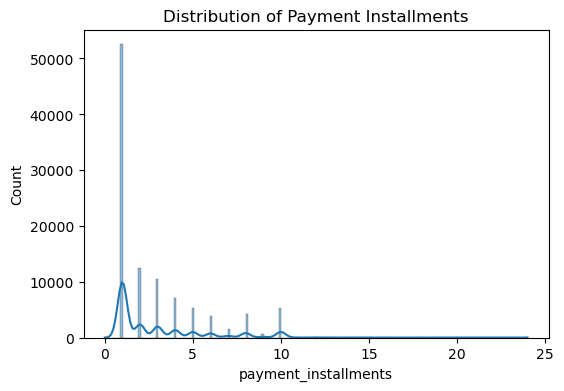

In [75]:
# Histogram and KDE of payment installments
plt.figure(figsize=(6,4))
sns.histplot(order_payments['payment_installments'], kde=True)
plt.title('Distribution of Payment Installments')
plt.show()

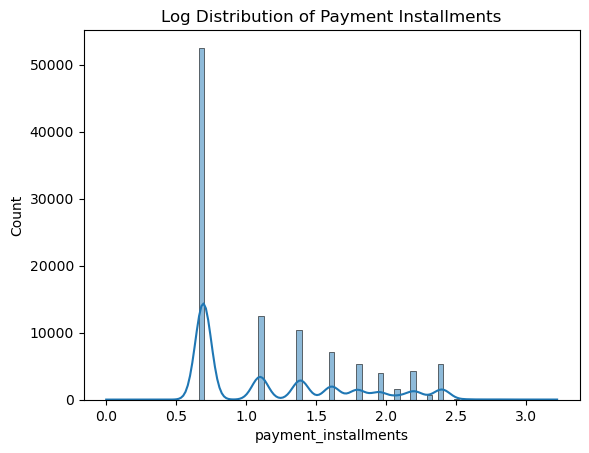

In [76]:
# Histogram and KDE of log of payments installments
sns.histplot(np.log1p(order_payments['payment_installments']), kde=True)
plt.title('Log Distribution of Payment Installments')
plt.show()

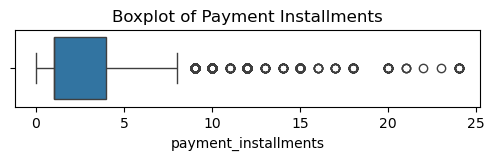

In [78]:
# Boxplot of payment installments
plt.figure(figsize=(6,1))
sns.boxplot(x=order_payments['payment_installments'])
plt.title('Boxplot of Payment Installments')
plt.show()

In [79]:
# Check skewness
order_payments['payment_installments'].skew()

1.6550737635551802

In [81]:
# Check outlier thresholds
Q1 = order_payments['payment_installments'].quantile(0.25)
Q3 = order_payments['payment_installments'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = order_payments[
    (order_payments['payment_installments'] < lower_bound) | 
    (order_payments['payment_installments'] > upper_bound)
]

print(f"Outliers found: {outliers.shape[0]} ({outliers.shape[0] / len(order_items) * 100:.2f}%)")
outliers['payment_installments'].describe()

Outliers found: 6313 (5.60%)


count    6313.000000
mean       10.143355
std         1.350214
min         9.000000
25%        10.000000
50%        10.000000
75%        10.000000
max        24.000000
Name: payment_installments, dtype: float64

In [85]:
# Check for zero installments
(order_payments['payment_installments'] == 0).sum()

2

In [87]:
# Check frequency
order_payments['payment_installments'].value_counts().sort_index()

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

##### Payment Installments Takeaways
1. **Typical payment behavior**
   - Median = 1 installment, mean = 2.85, showing most customers pay in full.  
   - 25% of customers pay in greater than or equal to 4 installments, with a maximum of 24 installments.  
   - Distribution has clear peaks at common plans (1, 2, 3, 6, 10, 12).  
<br>
<br>
2. **Skewness and outliers**
   - Right-skewed due to a smaller group using many installments.  
   - Boxplot shows most values are less than or equal to 6, but outliers extend to 20–24.  
<br>
<br>
3. **Zeros need attention**
   - A minimum value of 0 installments is invalid.  
   - These cases likely represent data entry errors or cancellations and should be cleaned.  
<br>
<br>
4. **Business implications**
   - Most customers prefer paying upfront, but installment options are still widely used.  
   - Higher installment counts may be linked to higher-value purchases.  This is worth checking against payment value later.  

#### Review Score Analysis

In [91]:
# Describe review score
order_reviews['review_score'].describe()

count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

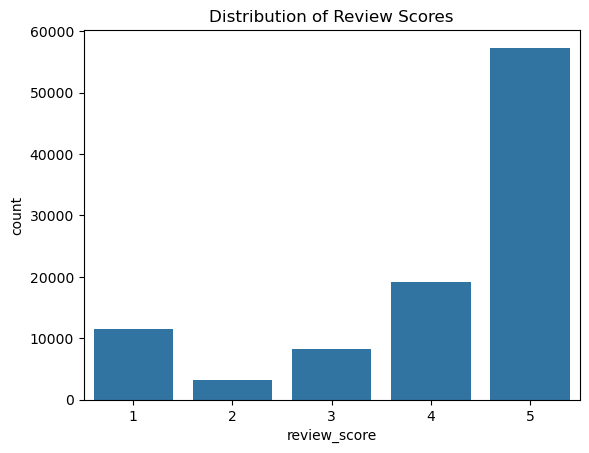

In [93]:
# Frequency plot of review score
sns.countplot(x='review_score', data=order_reviews)
plt.title('Distribution of Review Scores')
plt.show()

In [95]:
# Check for missing or invalid values
order_reviews['review_score'].isna().sum()
order_reviews['review_score'].unique()

array([4, 5, 1, 3, 2])

##### Review Score Takeaways
1. **Distribution is strongly positive**
   - Mean = 4.09, Median = 5, showing most customers are satisfied.  
   - 75% of reviews are greater than or equal to 4 stars, confirming a skew towards positive feedback.  
<br>
<br>
2. **Imbalance across review classes**
   - 5-star reviews dominate the dataset.  
   - 1–2 star reviews make up a smaller share but are important for understanding dissatisfaction.  
   - 3-star “neutral” reviews are relatively rare (~5%).  
<br>
<br>
3. **Central tendency**
   - High average and median review scores highlight overall customer satisfaction.  
   - The minority of low scores (1–2) will be valuable for churn/risk analysis.  
<br>
<br>
4. **Business implications**
   - Strong customer satisfaction overall, but negative reviews (1–2 stars) provide key insights for improvement.  
   - Class imbalance will need to be addressed in predictive modeling.  

#### Product Dimensions and Weight Analysis

In [99]:
# Describe product dimensions and weight
products[['product_weight_g', 'product_length_cm', 
          'product_height_cm', 'product_width_cm']].describe().T

,count,mean,std,min,25%,50%,75%,max
product_weight_g,32327.0,2276.960807,4279.734063,0.0,300.0,700.0,1900.0,40425.0
product_length_cm,32327.0,30.856498,16.958460,7.0,18.0,25.0,38.0,105.0
product_height_cm,32327.0,16.955950,13.637246,2.0,8.0,13.0,20.5,105.0
product_width_cm,32327.0,23.208464,12.080665,6.0,15.0,20.0,30.0,118.0


In [101]:
# Check product dimensions and weight for missing values
products[['product_weight_g','product_length_cm',
          'product_height_cm','product_width_cm']].isna().sum()

product_weight_g     0
product_length_cm    0
product_height_cm    0
product_width_cm     0
dtype: int64

Skewness: 3.6076941842483383
Kurtosis: 15.181688773651484


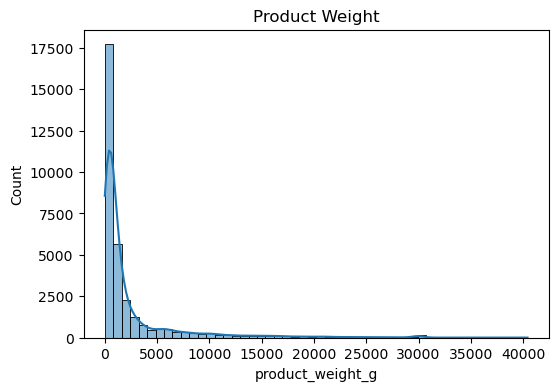

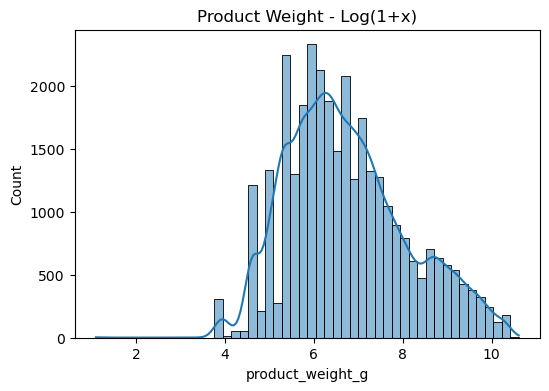

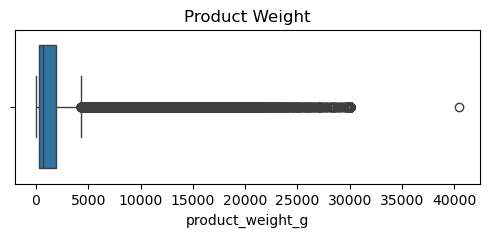

In [103]:
# Visualize product weight

# Check Skewness and Kurtosis
print('Skewness:', products['product_weight_g'].skew())
print('Kurtosis:', products['product_weight_g'].kurt())

# Histogram
plt.figure(figsize=(6,4))
sns.histplot(products['product_weight_g'], bins=50, kde=True)
plt.title('Product Weight')
plt.show()

# Log Histogram
weights = products[products['product_weight_g'] > 0]['product_weight_g']
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(weights), bins=50, kde=True)
plt.title('Product Weight - Log(1+x)')
plt.show()

# Boxplot
plt.figure(figsize=(6,2))
sns.boxplot(x=products['product_weight_g'])
plt.title('Product Weight')
plt.show()

Skewness: 1.7499329560492645
Kurtosis: 3.502532343162726


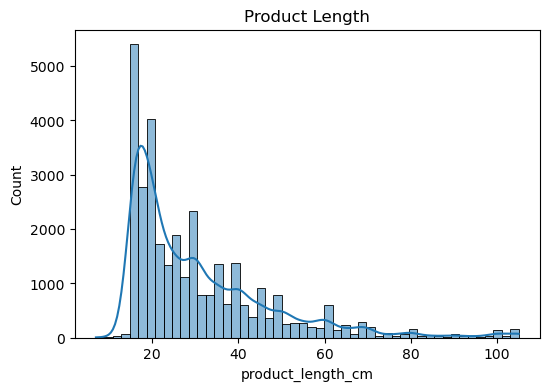

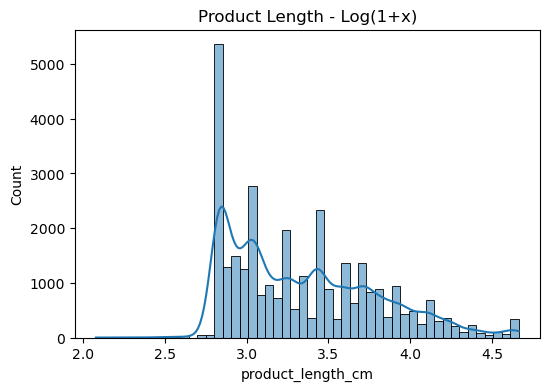

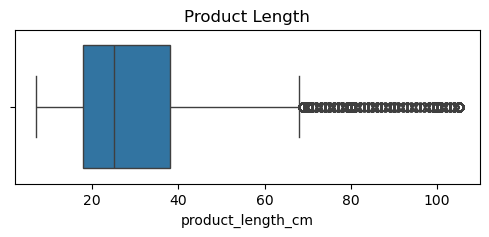

In [104]:
# Visualize product length

# Check Skewness and Kurtosis
print('Skewness:', products['product_length_cm'].skew())
print('Kurtosis:', products['product_length_cm'].kurt())

# Histogram
plt.figure(figsize=(6,4))
sns.histplot(products['product_length_cm'], bins=50, kde=True)
plt.title('Product Length')
plt.show()

# Log Histogram
lengths = products[products['product_length_cm'] > 0]['product_length_cm']
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(lengths), bins=50, kde=True)
plt.title('Product Length - Log(1+x)')
plt.show()

# Boxplot
plt.figure(figsize=(6,2))
sns.boxplot(x=products['product_length_cm'])
plt.title('Product Length')
plt.show()

Skewness: 2.1496595909056126
Kurtosis: 6.724647202538803


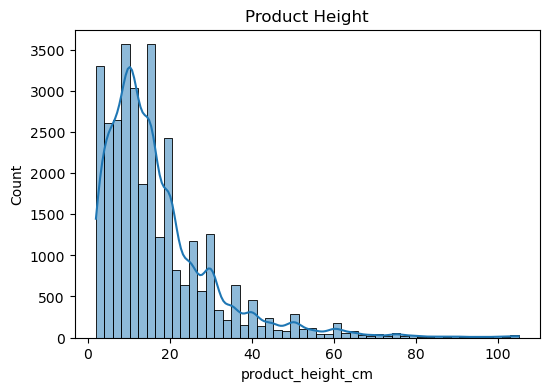

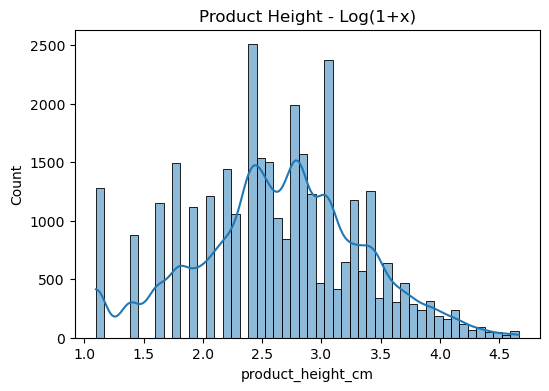

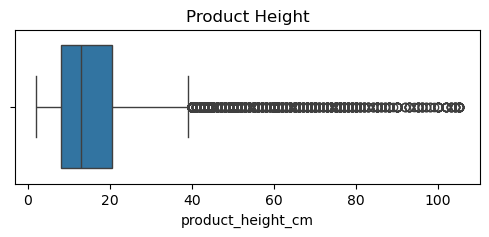

In [106]:
# Visualize product height

# Check Skewness and Kurtosis
print('Skewness:', products['product_height_cm'].skew())
print('Kurtosis:', products['product_height_cm'].kurt())

# Histogram
plt.figure(figsize=(6,4))
sns.histplot(products['product_height_cm'], bins=50, kde=True)
plt.title('Product Height')
plt.show()

# Log Histogram
heights = products[products['product_height_cm'] > 0]['product_height_cm']
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(heights), bins=50, kde=True)
plt.title('Product Height - Log(1+x)')
plt.show()

# Boxplot
plt.figure(figsize=(6,2))
sns.boxplot(x=products['product_height_cm'])
plt.title('Product Height')
plt.show()

Skewness: 1.6779106296360324
Kurtosis: 4.117332778655503


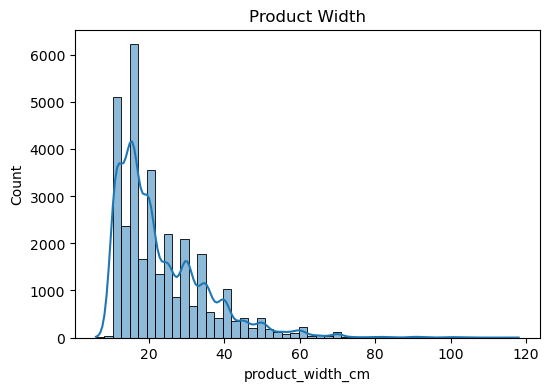

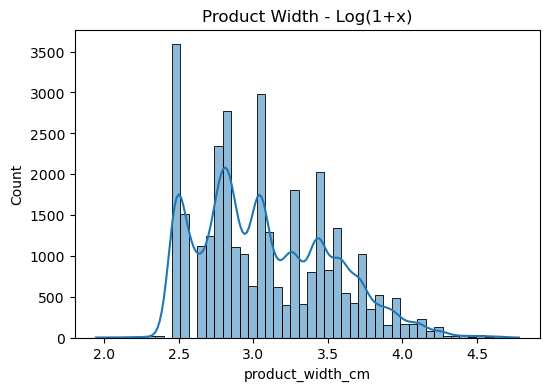

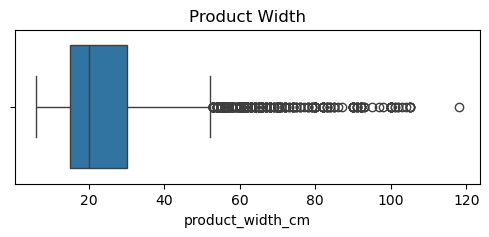

In [108]:
# Visualize product width

# Check Skewness and Kurtosis
print('Skewness:', products['product_width_cm'].skew())
print('Kurtosis:', products['product_width_cm'].kurt())

# Histogram
plt.figure(figsize=(6,4))
sns.histplot(products['product_width_cm'], bins=50, kde=True)
plt.title('Product Width')
plt.show()

# Log Histogram
widths = products[products['product_width_cm'] > 0]['product_width_cm']
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(widths), bins=50, kde=True)
plt.title('Product Width - Log(1+x)')
plt.show()

# Boxplot
plt.figure(figsize=(6,2))
sns.boxplot(x=products['product_width_cm'])
plt.title('Product Width')
plt.show()

##### Overall Takeaways: Product Dimensions and Weight

1. **No missing values**
   - No missing values were found in product dimensions or weight.
<br>
<br>
2. **All four variables show right-skewed distributions**
   - Weight, length, height, and width all show right skewed distributions with extreme outliers.
<br>
<br>
3. **Product Weight is the most skewed**
   - Mean is much lower than the median, indicating strong skewness.
   - Maximum weight (~40 kg) may represent oversized items or possible data entry issues.
   - Log transformation produces a bell-shaped distribution, suggesting skewness is driven by extreme values.
<br>
<br>
4. **Boxplots confirm the presence of many outliers**
   - Boxplots confirm outliers across all dimensions, but these may be valid given the diversity of product types.
<br>
<br>
5. **Next step**
   - Create Product Volume from length, height, and widgth to check for unusual item sizes.

#### Product Volume Analysis

In [111]:
# Create product volume
# volume = length * height * width
products['product_volume_cm3'] = (
    products['product_length_cm'] *
    products['product_height_cm'] *
    products['product_width_cm']
)

In [113]:
# Describe product volume
print(products['product_volume_cm3'].describe())

count     32327.000000
mean      16578.133356
std       27067.821121
min         168.000000
25%        2880.000000
50%        6859.000000
75%       18513.000000
max      296208.000000
Name: product_volume_cm3, dtype: float64


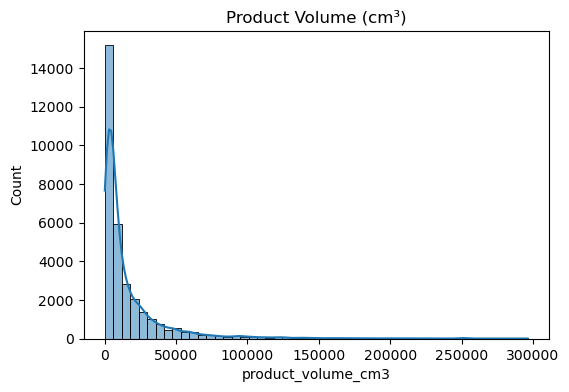

In [114]:
# Histogram of volume
plt.figure(figsize=(6,4))
sns.histplot(products['product_volume_cm3'].dropna(), bins=50, kde=True)
plt.title("Product Volume (cm³)")
plt.show()

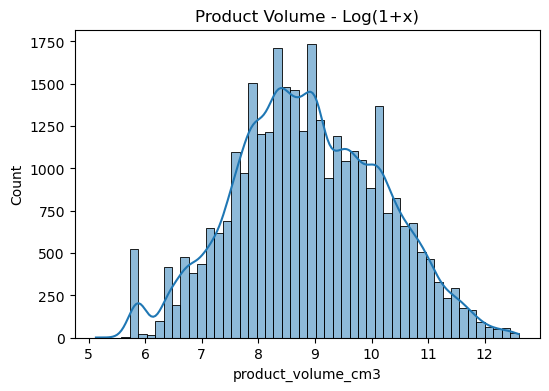

In [116]:
# Histogram of product volume log
positive_vol = products.loc[products['product_volume_cm3'] > 0, 'product_volume_cm3']
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(positive_vol), bins=50, kde=True)
plt.title("Product Volume - Log(1+x)")
plt.show()

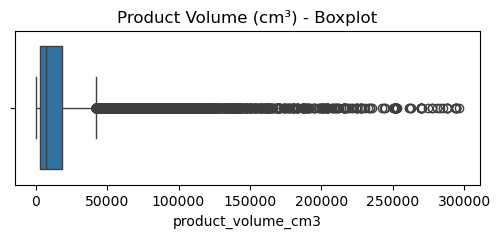

In [119]:
# Boxplot of volume
plt.figure(figsize=(6,2))
sns.boxplot(x=products['product_volume_cm3'])
plt.title("Product Volume (cm³) - Boxplot")
plt.show()

##### Product Volume Takeaways

1. **Central Tendency**
   - Median volume ≈ 6,859 cm³  
   - Mean volume ≈ 16,578 cm³ which is much larger than the median, showing strong right skew.
<br>
<br>
2. **Spread**
   - 25% of products < 2,880 cm³ 
   - 75% of products < 18,513 cm³
   - Maximum = 296,208 cm³, representing very large items such as furniture or appliances.
<br>
<br>
3. **Distribution**
   - Histogram: strongly right-skewed, with most products small/medium in size and a long tail of bulky items.
   - Log-transformed histogram: appears closer to normal, confirming skewness is driven by a few oversized products.  
   - Boxplot: many outliers are present, but these are expected in a diverse e-commerce catalog.
<br>
<br>
4. **Business implications**
   - Most Olist products are relatively compact. 
   - Extreme outliers (>100,000 cm³) likely represent furniture/appliances or possible data entry errors.

### ii. Categorical Values

#### Product Category Names in English Analysis

In [126]:
# Product category names value counts
products['product_category_name_english'].value_counts()

product_category_name_english
bed_bath_table               3029
sports_leisure               2867
furniture_decor              2657
health_beauty                2444
housewares                   2335
                             ... 
tablets_printing_image          9
home_comfort_2                  5
fashion_childrens_clothes       5
security_and_services           2
cds_dvds_musicals               1
Name: count, Length: 71, dtype: int64

In [128]:
# Calculate proportions for product category names
products['product_category_name_english'].value_counts(normalize=True).head(10)

product_category_name_english
bed_bath_table           0.093699
sports_leisure           0.088687
furniture_decor          0.082191
health_beauty            0.075602
housewares               0.072231
auto                     0.058774
computers_accessories    0.050701
toys                     0.043648
watches_gifts            0.041111
telephony                0.035079
Name: proportion, dtype: float64

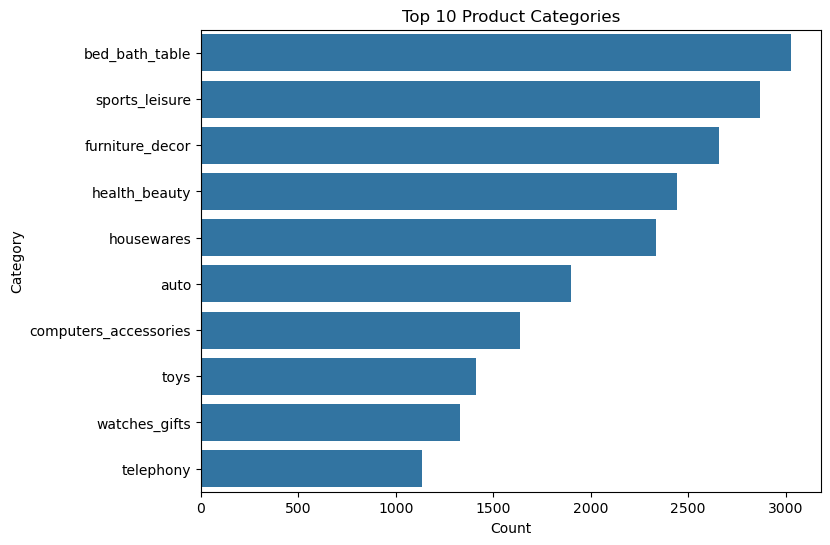

In [130]:
# Bar plot of top ten categories
plt.figure(figsize=(8,6))
sns.countplot(
    data=products,
    y='product_category_name_english',
    order=products['product_category_name_english'].value_counts().index[:10]
)
plt.title("Top 10 Product Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

In [132]:
# Check for missing or unknown values
products['product_category_name_english'].isna().sum()

0

##### Product Category (English) Takeaways

1. **No missing values**
   - No missing values were found in the product category column.
<br>
<br>
2. **There are 71 unique product categories in the dataset**
<br>
<br>
3. **The distribution is highly imbalanced**
   - The most common categories are bed_bath_table (9.4%), sports_leisure (8.9%), and furniture_decor (8.2%).  
   - The top 10 categories together account for more than 60% of all products.  
   - Many categories are very rare (some with fewer than 10 products).  
<br>
<br>
4. **Visualizations confirm**:
   - A small set of categories dominate the dataset.  
   - A “long tail” of niche categories exists, which may need to be grouped into `"other"` for analysis or modeling.  

#### Order Status Analysis

In [136]:
# Check order status proportions
orders['order_status'].value_counts(normalize=True).sort_values(ascending=False)

order_status
delivered      0.970203
shipped        0.011132
canceled       0.006285
unavailable    0.006124
invoiced       0.003158
processing     0.003027
created        0.000050
approved       0.000020
Name: proportion, dtype: float64

<Figure size 1200x600 with 0 Axes>

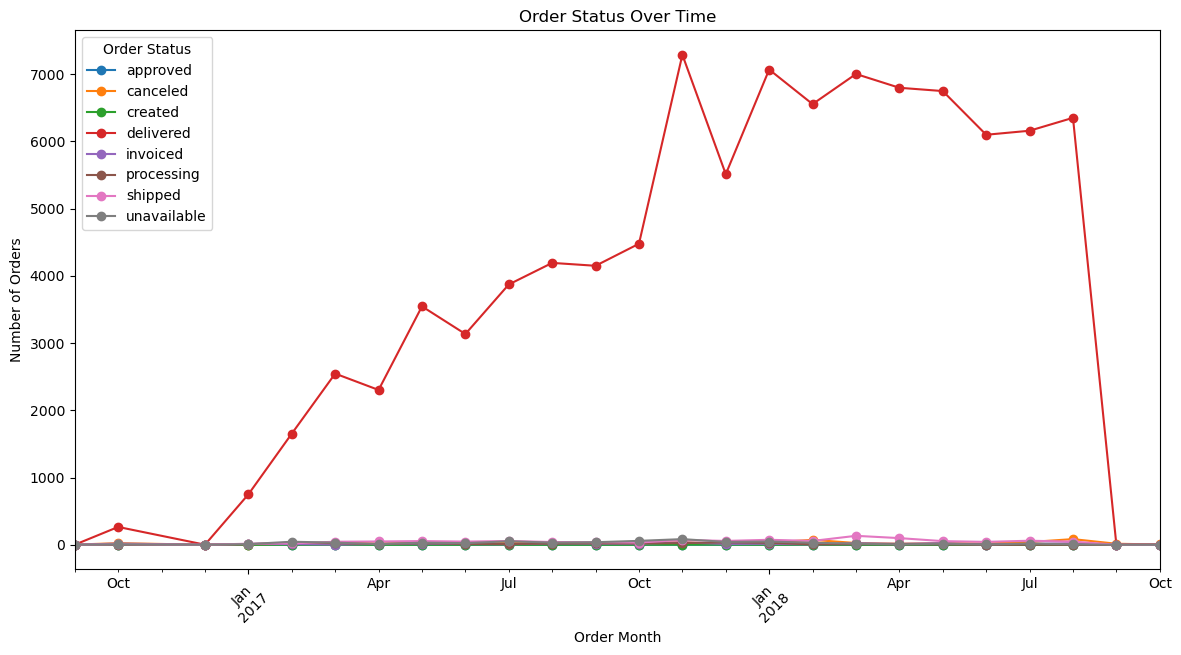

In [138]:
# Check time evolution of order status
# Create a month column
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Group by month and status
status_trend = (
    orders.groupby(['order_month', 'order_status'], observed=True)
          .size()
          .reset_index(name='count')
)

# Pivot so each status is a column
status_pivot = status_trend.pivot(index='order_month', columns='order_status', values='count').fillna(0)

# Plot
plt.figure(figsize=(12,6))
status_pivot.plot(kind='line', marker='o', figsize=(14,7))
plt.title('Order Status Over Time')
plt.xlabel('Order Month')
plt.ylabel('Number of Orders')
plt.legend(title='Order Status')
plt.xticks(rotation=45)
plt.show()

In [139]:
# Complete pipeline analysis
pipeline_counts = (
    orders['order_status']
    .map({
        'created': 'Created',
        'processing': 'Created',
        'invoiced': 'Created',
        'approved': 'Approved',
        'shipped': 'Shipped',
        'delivered': 'Delivered',
        'canceled': 'Not Completed',
        'unavailable': 'Not Completed'
    })
    .value_counts()
)

pipeline_counts

order_status
Delivered        96478
Not Completed     1234
Shipped           1107
Created            620
Approved             2
Name: count, dtype: int64

In [142]:
# Calculate drop-off percentages
pipeline_percent = (pipeline_counts / pipeline_counts.sum()) * 100
pipeline_percent

order_status
Delivered        97.020344
Not Completed     1.240937
Shipped           1.113223
Created           0.623485
Approved          0.002011
Name: count, dtype: float64

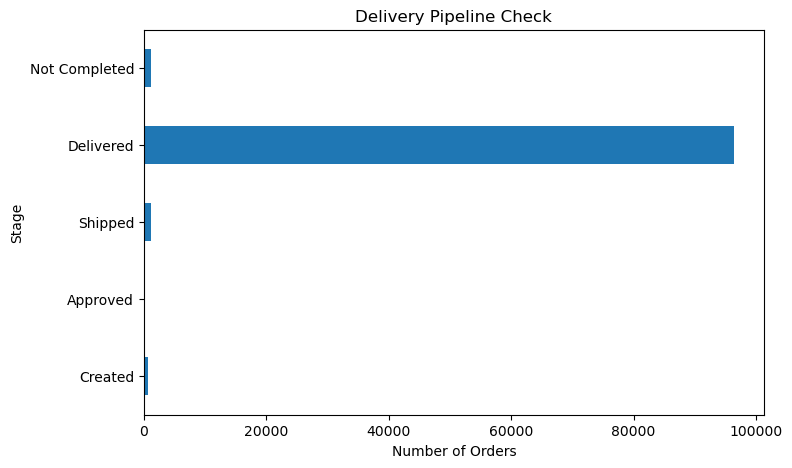

In [144]:
#Visualize delivery status funnel
pipeline_counts = pipeline_counts.reindex(['Created','Approved','Shipped','Delivered','Not Completed'])

pipeline_counts.plot(kind='barh', figsize=(8,5))
plt.title("Delivery Pipeline Check")
plt.xlabel("Number of Orders")
plt.ylabel("Stage")
plt.show()

##### Order Status Analysis Takeaways

1. **Delivered dominates**  
   - 97% of orders are successfully delivered.  
<br>
<br>
2. **Low cancellation rate**  
   - Only 1.2% of orders end up as Not Completed. 
<br>
<br>
3. **Time trend**  
   - Delivered orders ramp up steadily from late 2016, peak mid-2018, then taper down.
   - Non-delivered statuses remain consistently low, with no major spikes.  
<br>
<br>
4. **Business implications**
   - A 97% delivery success rate shows Olist’s logistics and fulfillment process is highly reliable.  
   - 1,200+ orders were Not Completed. Even a small recovery here could yield meaningful revenue gains at scale.  
   - Investigating cancellations by product category, payment type, or customer region could highlight weak spots.  
   - Growth peaked in mid-2018 before slowing. This may indicate market saturation or rising competition.

#### Payment Methods Analysis

In [148]:
# Count payment types
payment_counts = order_payments['payment_type'].value_counts(normalize=True) * 100
print(payment_counts)

payment_type
credit_card    73.922376
boleto         19.043952
voucher         5.558978
debit_card      1.471806
not_defined     0.002888
Name: proportion, dtype: float64


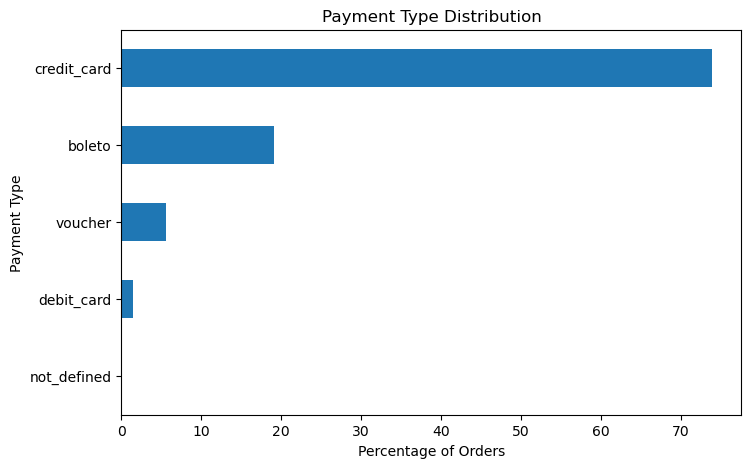

In [150]:
#Bar plot
plt.figure(figsize=(8,5))
payment_counts.sort_values().plot(kind='barh')
plt.title("Payment Type Distribution")
plt.xlabel("Percentage of Orders")
plt.ylabel("Payment Type")
plt.show()

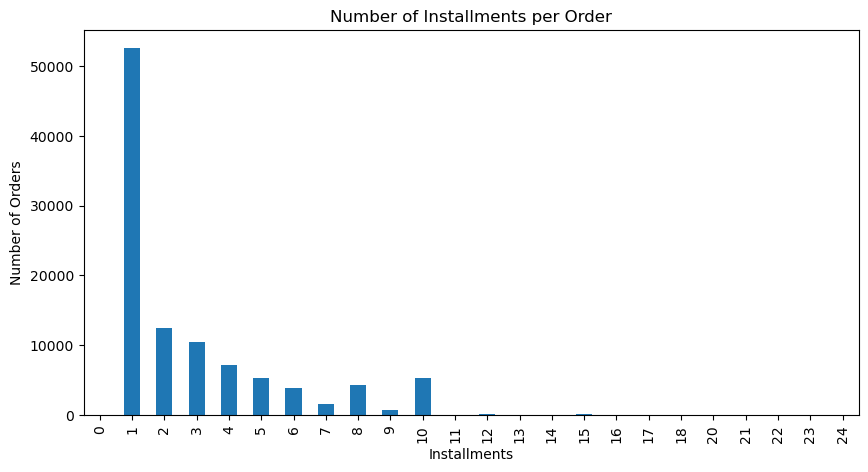

payment_installments
0        2
1    52546
2    12413
3    10461
4     7098
5     5239
6     3920
7     1626
8     4268
9      644
Name: count, dtype: int64

In [152]:
# Distribution of installments
installment_counts = order_payments['payment_installments'].value_counts().sort_index()

plt.figure(figsize=(10,5))
installment_counts.plot(kind='bar')
plt.title("Number of Installments per Order")
plt.xlabel("Installments")
plt.ylabel("Number of Orders")
plt.show()

installment_counts.head(10)

In [154]:
# Average installments by payment type
avg_installments = (
    order_payments.groupby('payment_type', observed=True)['payment_installments']
    .mean()
    .sort_values(ascending=False)
)

avg_installments

payment_type
credit_card    3.507155
boleto         1.000000
debit_card     1.000000
not_defined    1.000000
voucher        1.000000
Name: payment_installments, dtype: float64

##### Payment Method Analysis Takeaways

1. **Credit card dominates**  
   - Around 74% of all orders are paid with credit cards, making it the most important payment channel.  
<br>
<br>
2. **Boleto is significant**  
   - About 19% of transactions use boleto, showing that alternative methods remain important in Brazilian e-commerce.  
<br>
<br>
3. **Other methods are minor**  
   - Vouchers (5.6%), debit cards (1.5%), and undefined payments (<0.01%) make up a small share of total transactions.  
<br>
<br>
4. **Installments are common**  
   - The majority of credit card payments are made in installments. Most frequently, customers pay in 1 installment (~52k orders), but many use 2–6 installments, with some extending up to 10 or more.  
<br>
<br>
5. **Average installments by payment type**  
   - Credit card orders average ~3.5 installments. All other payment methods (boleto, debit card, voucher) are almost always paid in a single installment.  
<br>
<br>
6. **Business Implications**
   - With nearly three-quarters of payments via credit card, the platform is heavily dependent on this channel. Ensuring smooth processing and strong partnerships with credit providers is critical.  
   - The reliance on 2–6 installments for many credit card transactions reflects consumer preference for splitting payments. Flexible installment options may directly boost sales, especially for higher-ticket items.  
   - The sizable share of boleto payments highlights the need to support customers who lack or avoid credit cards. Maintaining boleto as an option expands reach to less-banked populations.  
   - Heavy reliance on credit cards means the business may face risks if card networks change fees or approval processes. Expanding alternative payment adoption could diversify revenue stability.  
   - Payment type and installment behavior can be strong signals for segmenting customers by financial flexibility and risk, enabling tailored marketing and credit offerings.  

#### Customer State Analysis

In [158]:
# Count customers per state
cust_state_counts = customers['customer_state'].value_counts(normalize=True) * 100
print(cust_state_counts)

customer_state
SP    41.980672
RJ    12.924247
MG    11.700405
RS     5.496727
PR     5.073360
SC     3.657445
BA     3.399000
DF     2.152030
ES     2.044428
GO     2.031355
PE     1.661287
CE     1.343510
PA     0.980481
MT     0.912099
MA     0.751199
MS     0.719019
PB     0.539013
PI     0.497783
RN     0.487726
AL     0.415322
SE     0.351967
TO     0.281574
RO     0.254422
AM     0.148832
AC     0.081455
AP     0.068382
RR     0.046259
Name: proportion, dtype: float64


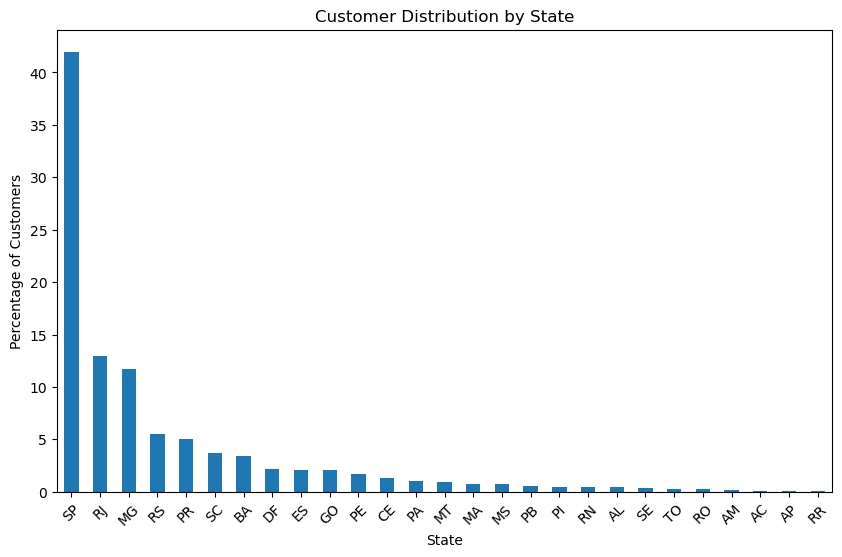

In [160]:
# Bar plot
plt.figure(figsize=(10,6))
cust_state_counts.sort_values(ascending=False).plot(kind='bar')
plt.title("Customer Distribution by State")
plt.xlabel("State")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=45)
plt.show()

In [162]:
# Top 10 customer states
cust_state_counts.head(10)

customer_state
SP    41.980672
RJ    12.924247
MG    11.700405
RS     5.496727
PR     5.073360
SC     3.657445
BA     3.399000
DF     2.152030
ES     2.044428
GO     2.031355
Name: proportion, dtype: float64

#### Seller State Analysis

In [165]:
# Count sellers per state
seller_state_counts = sellers['seller_state'].value_counts(normalize=True) * 100
print(seller_state_counts)

seller_state
SP    59.741519
PR    11.276252
MG     7.883683
SC     6.138934
RJ     5.525040
RS     4.168013
GO     1.292407
DF     0.969305
ES     0.743134
BA     0.613893
CE     0.420032
PE     0.290792
PB     0.193861
MS     0.161551
RN     0.161551
MT     0.129241
RO     0.064620
SE     0.064620
AC     0.032310
PI     0.032310
AM     0.032310
MA     0.032310
PA     0.032310
Name: proportion, dtype: float64


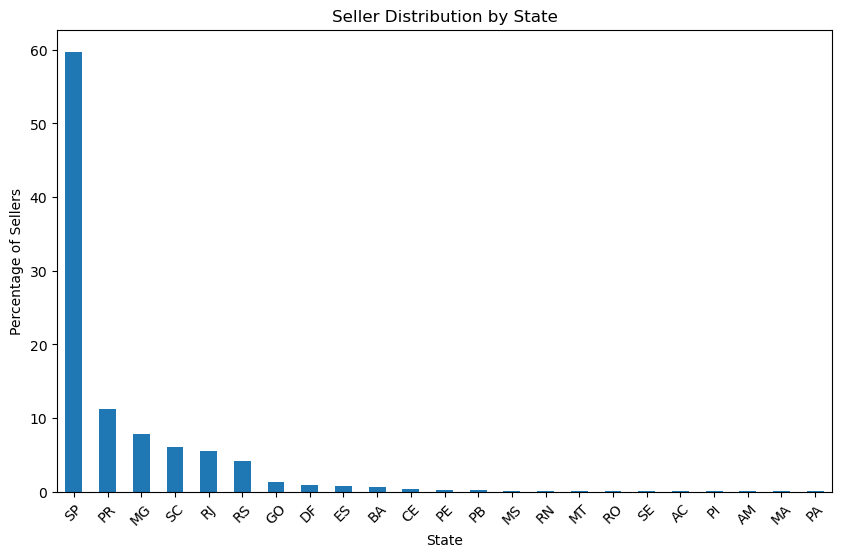

In [167]:
# Bar plot
plt.figure(figsize=(10,6))
seller_state_counts.sort_values(ascending=False).plot(kind='bar')
plt.title("Seller Distribution by State")
plt.xlabel("State")
plt.ylabel("Percentage of Sellers")
plt.xticks(rotation=45)
plt.show()

In [169]:
# Top 10 seller states
seller_state_counts.head(10)

seller_state
SP    59.741519
PR    11.276252
MG     7.883683
SC     6.138934
RJ     5.525040
RS     4.168013
GO     1.292407
DF     0.969305
ES     0.743134
BA     0.613893
Name: proportion, dtype: float64

##### Customer and Seller State Takeaways

1. **Customer concentration**  
   - São Paulo (SP) alone accounts for ~42% of customers.  
   - Rio de Janeiro (RJ) and Minas Gerais (MG) follow with ~13% and ~12%, respectively.  
   - The top 3 states represent nearly 70% of all customers.  
<br>
<br>
2. **Seller concentration**  
   - São Paulo (SP) is even more dominant on the supply side, with ~60% of all sellers.  
   - Paraná (PR), Minas Gerais (MG), and Santa Catarina (SC) follow, each between 6–11%.  
   - Seller distribution is more concentrated than customer distribution.  
<br>
<br>
3. **Geographic imbalance**  
   - Customers are somewhat more spread out across states, while sellers are highly concentrated in SP.  
   - Smaller states contribute only marginally to either demand or supply.  
<br>
<br>
4. **Business Implications**
   - With most sellers clustered in São Paulo, logistics networks can be optimized around this hub. However, deliveries to distant states may face longer lead times and higher shipping costs.  
   - The heavy concentration of customers in SP, RJ, and MG means growth strategies could focus on penetrating mid-tier states to diversify demand.  
   - Overreliance on São Paulo for both demand and supply poses a risk. Any disruption in this region could significantly impact business. Diversifying the seller base geographically could mitigate this.  
   - If sellers are mostly in SP but customers are spread across Brazil, ensuring fast and reliable delivery to distant regions is critical to maintain satisfaction.  

## D. Bivariate Analysis

### i. Correlation Heatmap of Numerical Features

In [174]:
# Merge tables

# Assert uniqueness
assert orders['order_id'].is_unique

o = orders.copy()

# Parse dates
date_cols = ['order_purchase_timestamp','order_approved_at',
             'order_delivered_carrier_date','order_delivered_customer_date',
             'order_estimated_delivery_date']
o[date_cols] = o[date_cols].apply(pd.to_datetime)

# Delivery-related features
o['approval_lag_days']   = (o['order_approved_at'] - o['order_purchase_timestamp']).dt.total_seconds()/86400
o['ship_lag_days']       = (o['order_delivered_carrier_date'] - o['order_approved_at']).dt.total_seconds()/86400
o['delivery_time_days']  = (o['order_delivered_customer_date'] - o['order_purchase_timestamp']).dt.total_seconds()/86400
o['delay_vs_est_days']   = (o['order_delivered_customer_date'] - o['order_estimated_delivery_date']).dt.total_seconds()/86400

# Keep columns to be used later
orders_agg = o[['order_id','customer_id','order_status',
                'approval_lag_days','ship_lag_days','delivery_time_days','delay_vs_est_days']]

In [176]:
# Aggregate items

it = order_items.copy()

items_agg = (
    it.groupby('order_id', observed=False)
      .agg(
          items_n            = ('order_item_id','count'),
          order_price_sum    = ('price','sum'),
          order_freight_sum  = ('freight_value','sum'),
          sellers_n          = ('seller_id','nunique'),
          products_n         = ('product_id','nunique')
      )
      .reset_index()
)

items_agg['order_value'] = items_agg['order_price_sum'] + items_agg['order_freight_sum']

In [178]:
# Aggregate payments

p = order_payments.copy()

# Sum value; summarize installments; one-hot payment types then aggregate
pay_type_dummies = pd.get_dummies(p['payment_type'], prefix='pay')
p_dum = pd.concat([p[['order_id','payment_value','payment_installments']], pay_type_dummies], axis=1)

payments_agg = (
    p_dum.groupby('order_id', observed=False)
         .agg(
             total_payment_value   = ('payment_value','sum'),
             max_installments      = ('payment_installments','max'),
             pay_boleto_n          = ('pay_boleto','sum'),
             pay_credit_card_n     = ('pay_credit_card','sum'),
             pay_debit_card_n      = ('pay_debit_card','sum'),
             pay_voucher_n         = ('pay_voucher','sum'),
             payments_count        = ('payment_value','count')
         )
         .reset_index()
)

for c in ['pay_boleto_n','pay_credit_card_n','pay_debit_card_n','pay_voucher_n']:
    payments_agg[c.replace('_n','_any')] = (payments_agg[c] > 0).astype(int)

In [180]:
r = order_reviews.copy()
r['review_creation_date'] = pd.to_datetime(r['review_creation_date'])

reviews_latest = (
    r.sort_values(['order_id','review_creation_date'])
     .groupby('order_id', observed=False)
     .tail(1)[['order_id','review_score','review_creation_date']]
     .reset_index(drop=True)
)

In [182]:
cust_cols = ['customer_id','customer_unique_id','customer_city','customer_state']
customers_slim = customers[cust_cols].drop_duplicates('customer_id')

In [184]:
# Merge left onto orders
def safe_left_merge(left, right, on):
    before = len(left)
    out = left.merge(right, on=on, how='left', validate='one_to_one' if right[on].is_unique else 'one_to_many')
    after = len(out)
    assert after == before, f"Row count changed: {before} -> {after}"
    return out

# Start from orders
df = orders_agg.copy()

# Merge items
df = safe_left_merge(df, items_agg, on='order_id')

# Merge payments
df = safe_left_merge(df, payments_agg, on='order_id')

# Merge reviews
df = safe_left_merge(df, reviews_latest, on='order_id')

# Merge customers
df = df.merge(customers_slim, on='customer_id', how='left', validate='many_to_one')

In [185]:
# Grain check
assert df['order_id'].is_unique, "Grain broke: duplicate orders present."

# Coverage checks
print('Orders with items:', df['items_n'].notna().mean())
print('Orders with payments:', df['total_payment_value'].notna().mean())
print('Orders with review:', df['review_score'].notna().mean())

# Validity checks
# Payment roughly equals computed order value
diff = np.abs(df['total_payment_value'] - df['order_value'])
print('Median |payment - order_value|:', np.nanmedian(diff))

# Time deltas reasonable
for c in ['approval_lag_days','ship_lag_days','delivery_time_days','delay_vs_est_days']:
    print(c, df[c].describe(percentiles=[.01,.5,.99]))

Orders with items: 0.9922064339658692
Orders with payments: 0.9999899437857624
Orders with review: 0.9922768274655324
Median |payment - order_value|: 0.0
approval_lag_days count    99281.000000
mean         0.434129
std          1.084917
min          0.000000
1%           0.000000
50%          0.014306
99%          3.756937
max        187.882523
Name: approval_lag_days, dtype: float64
ship_lag_days count    97644.000000
mean         2.805038
std          3.549427
min       -171.219005
1%          -0.069482
50%          1.818397
99%         17.150946
max        125.762569
Name: ship_lag_days, dtype: float64
delivery_time_days count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
1%           1.825203
50%         10.217755
99%         46.049913
max        209.628611
Name: delivery_time_days, dtype: float64
delay_vs_est_days count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
1%         -35.154239
50%        -11.948941


In [188]:
# Dropping orders not marked as delivered
df_clean = df[df['order_status'].eq('delivered')].copy()

In [190]:
# Dropping impossible deltas in delivery times
for c in ['approval_lag_days','ship_lag_days','delivery_time_days','delay_vs_est_days']:
    df_clean.loc[df_clean[c] < -1, c] = pd.NA
    df_clean.loc[df_clean[c] > 200, c] = pd.NA

In [192]:
# Sanity check
assert df['order_id'].is_unique
assert len(df) == len(df_clean) or len(df_clean) < len(df)

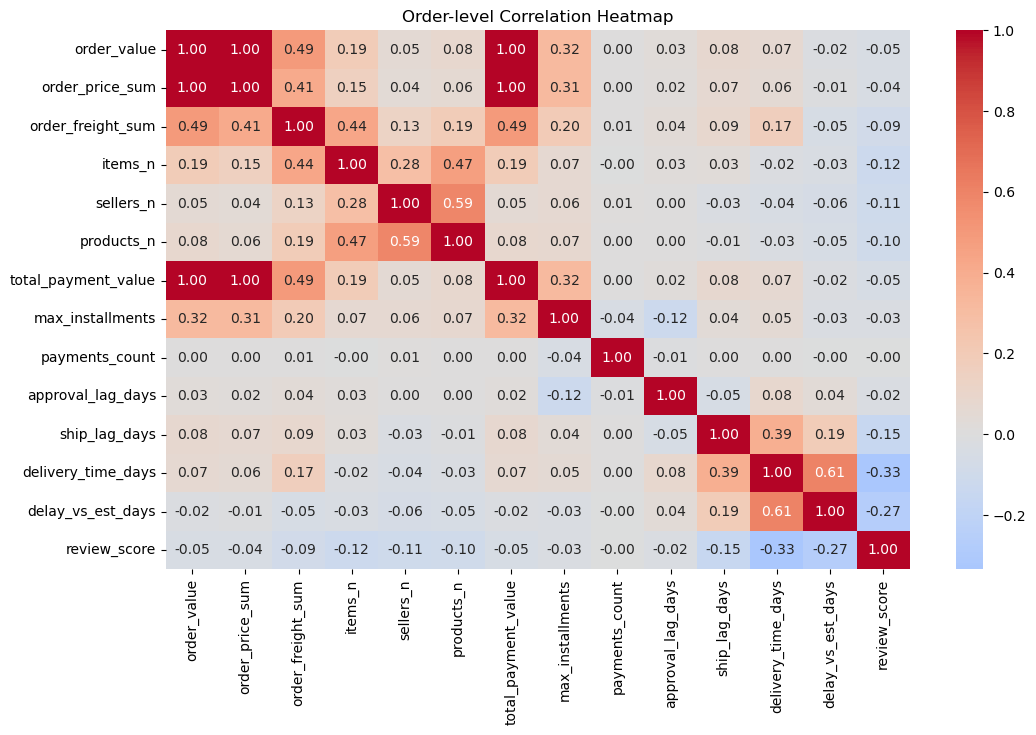

In [194]:
# Create order-level correlation heatmap
num_cols = [
    'order_value','order_price_sum','order_freight_sum','items_n','sellers_n','products_n',
    'total_payment_value','max_installments','payments_count',
    'approval_lag_days','ship_lag_days','delivery_time_days','delay_vs_est_days',
    'review_score'
]

num_df = df[num_cols].apply(pd.to_numeric, errors='coerce')
corr = num_df.corr(method='pearson')

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,7))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="coolwarm")
plt.title("Order-level Correlation Heatmap")
plt.show()

##### Correlation Heatmap Takeaways

1. **Redundant features**  
   - `order_value`, `order_price_sum`, and `total_payment_value` are perfectly correlated.  
   - To avoid issues in modeling, keep only one.
<br>
<br>
2. **Freight vs. Price**  
   - Moderate positive correlation (~0.49).  
   - Higher priced orders tend to have higher shipping costs, though freight still adds independent signal.
<br>
<br>
3. **Order complexity**  
   - `items_n`, `sellers_n`, and `products_n` are moderately correlated with each other.  
   - Multi-item, multi-seller orders introduce complexity and may influence delivery dynamics.
<br>
<br>
4. **Installments**  
   - `max_installments` correlates with `order_value` (~0.32).  
   - Larger orders are more likely to be paid in installments.
<br>
<br>
5. **Delivery metrics**  
   - `delivery_time_days` and `delay_vs_est_days` are strongly correlated (0.61).  
   - Longer delivery times strongly associate with late deliveries.  
   - `ship_lag_days` also relates moderately to delivery time (0.39).
<br>
<br>
6. **Review Score relationships**  
   - Negative correlations with delivery metrics:  
   - `delivery_time_days` (−0.33)  
   - `delay_vs_est_days` (−0.27)  
   - `ship_lag_days` (−0.15)  
   - Slightly negative correlations with order complexity (`items_n`, `sellers_n`, `products_n`).  
   - No meaningful correlation with price or payment value.  
   - **Key insight:** Customer satisfaction is most affected by timeliness, not price.
<br>
<br>
7. **Overall:** Customers don’t punish higher order values or shipping costs, but they do penalize late or complex deliveries in their reviews.

### ii. Order Value vs Freight Value (~ 0.49 correlation)

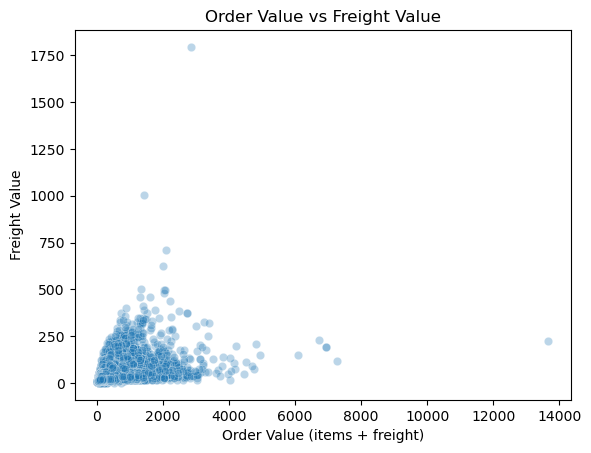

In [198]:
# Scatterplot of order value vs freight value
sns.scatterplot(
    x="order_value", 
    y="order_freight_sum", 
    data=df, 
    alpha=0.3
)
plt.title("Order Value vs Freight Value")
plt.xlabel("Order Value (items + freight)")
plt.ylabel("Freight Value")
plt.show()

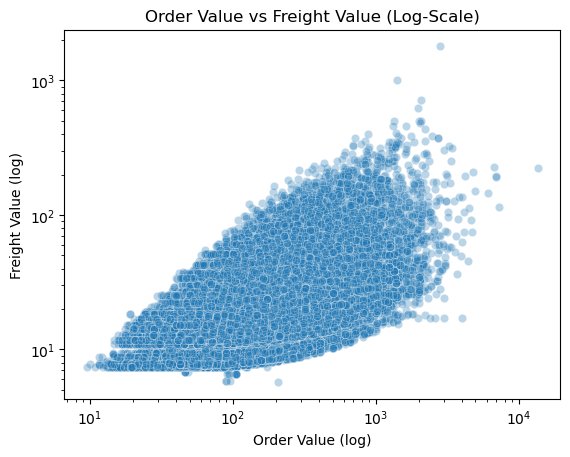

In [200]:
# Plot again with a log scale
sns.scatterplot(
    x="order_value", 
    y="order_freight_sum", 
    data=df, 
    alpha=0.3
)
plt.xscale("log")
plt.yscale("log")
plt.title("Order Value vs Freight Value (Log-Scale)")
plt.xlabel("Order Value (log)")
plt.ylabel("Freight Value (log)")
plt.show()

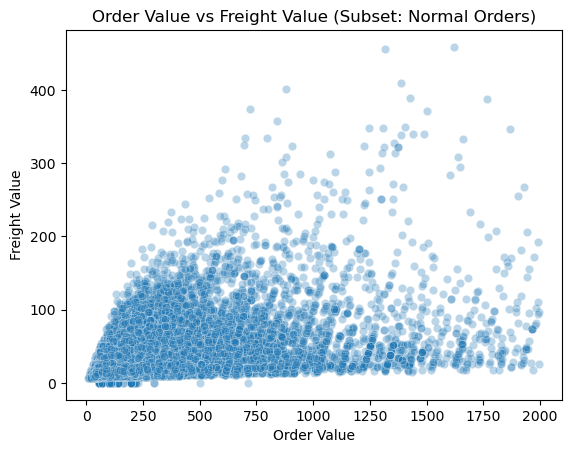

In [201]:
# Plot typical orders
subset = df[(df['order_value'] < 2000) & (df['order_freight_sum'] < 500)]

sns.scatterplot(
    x="order_value", 
    y="order_freight_sum", 
    data=subset, 
    alpha=0.3
)
plt.title("Order Value vs Freight Value (Subset: Normal Orders)")
plt.xlabel("Order Value")
plt.ylabel("Freight Value")
plt.show()

##### Over Value vs Freight Value Takeaways

   - Freight cost rises with order value but with high variance (corr ≈ 0.49).  
   - On a log–log scale the relationship is clearer: larger orders tend to cost more to ship proportionally.  
   - Outliers mask the typical trend and most orders show freight below **R\$200** for order values under **R\$2,000**.  
   - Business insight: freight is not simply a function of order value. Product characteristics and delivery distance introduce variation, making freight a valuable independent predictor.

### iii. Delivery Timeliness vs Review Score (~ -0.33 correlation)

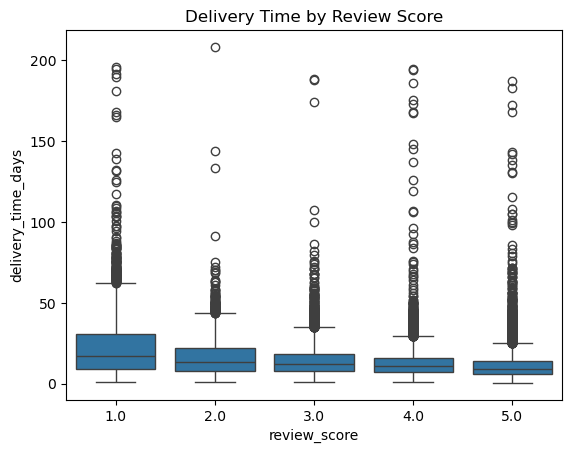

In [206]:
# Plot delivery times vs review score
sns.boxplot(x="review_score", y="delivery_time_days", data=df)
plt.title("Delivery Time by Review Score")
plt.show()

##### Delivery Time vs Review Score Takeaways

- Longer delivery times are associated with lower customer satisfaction (corr ≈ –0.33).
- 1-star reviews often have very long delivery times, with many extreme outliers (50+ days).
- 5-star reviews cluster around shorter delivery times (~10 days or less).
- Customers appear tolerant of moderate delivery times, but extreme waits (>20 days) sharply increase the likelihood of poor reviews.
- Business insight: reducing delivery delays, particularly long-tail cases, is critical for improving review scores.

### iv. Delivery Delay vs Review Score (~ -0.27 correlation)

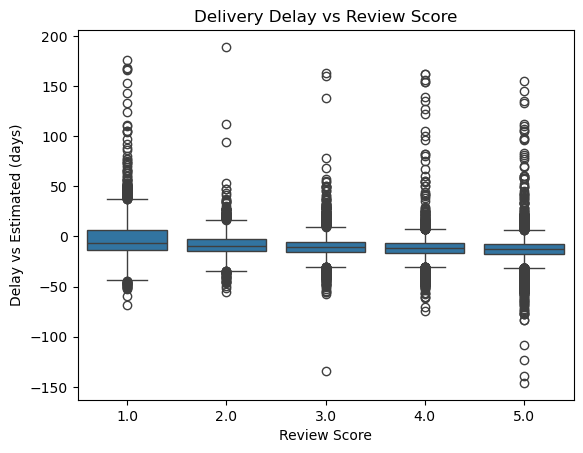

In [210]:
# Plot delay vs est vs review score
sns.boxplot(x="review_score", y="delay_vs_est_days", data=df)
plt.title("Delivery Delay vs Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delay vs Estimated (days)")
plt.show()

##### Delivery Delay vs Review Score Takeaways

- Longer delays relative to estimated delivery are associated with lower satisfaction (corr ≈ –0.27).
- 1–2 star reviews often correspond to orders delivered well past the promised date.
- 5-star reviews are concentrated around on-time or early deliveries (delay ≤ 0).
- Small delays may be tolerated, but large delays (>20 days) sharply increase the risk of poor reviews.
- Business insight: managing delivery promises and meeting (or beating) estimated dates is key to improving customer satisfaction.

### v. Items vs Review Score (~ -0.12 correlation)

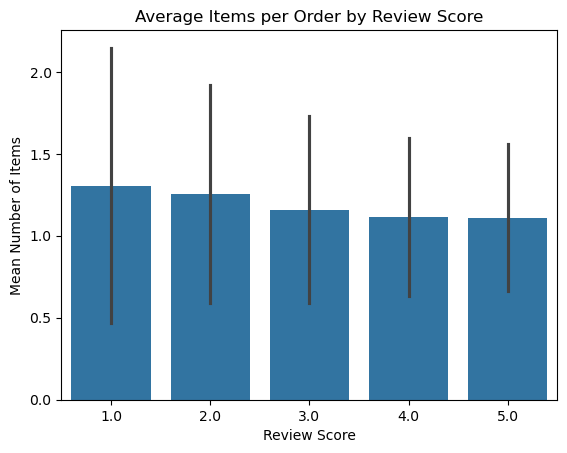

In [214]:
# Plot items_n vs review score
sns.barplot(x="review_score", y="items_n", data=df, estimator=np.mean, errorbar="sd")
plt.title("Average Items per Order by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Mean Number of Items")
plt.show()

##### Items vs Review Score Takeaways

- Weak negative correlation (≈ –0.12): lower review scores tend to have slightly more items per order.  
- Most orders contain just 1–2 items, regardless of review score, so the overall effect is small.  
- Larger, more complex orders may introduce more chances for delays or errors, but delivery timeliness remains a far stronger driver of satisfaction.  

### vi. Max Installments vs Order Value (~ 0.32 correlation)

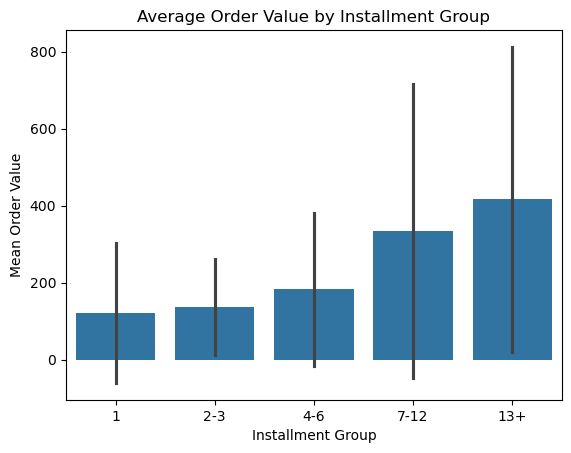

In [218]:
# Plot max installments vs order value
df['installment_bin'] = pd.cut(
    df['max_installments'],
    bins=[0,1,3,6,12,24],
    labels=["1","2-3","4-6","7-12","13+"]
)

sns.barplot(x="installment_bin", y="order_value", data=df,
            estimator=np.mean, errorbar="sd")
plt.title("Average Order Value by Installment Group")
plt.xlabel("Installment Group")
plt.ylabel("Mean Order Value")
plt.show()

##### Max Installments vs Order Value Takeaways

- Larger orders are more likely to be paid in multiple installments (corr ≈ 0.32).
- Orders with 7–12 installments average **~R\$300+**, while those with 13+ installments average **~R\$400–420**.
- High variance in higher installment groups: not all big orders use many installments, and some small orders still do.
- Business insight: installment usage signals high-value orders, useful for segmentation, but is a weaker driver of customer satisfaction compared to delivery metrics.

### vii. Ship Lag vs Delivery Time (~ 0.39 correlation)

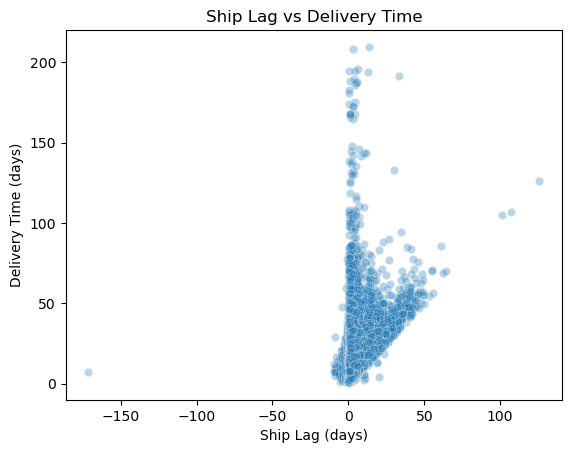

In [222]:
# Plot ship lag vs delivery time
sns.scatterplot(
    x="ship_lag_days", 
    y="delivery_time_days", 
    data=df, 
    alpha=0.3
)
plt.title("Ship Lag vs Delivery Time")
plt.xlabel("Ship Lag (days)")
plt.ylabel("Delivery Time (days)")
plt.show()

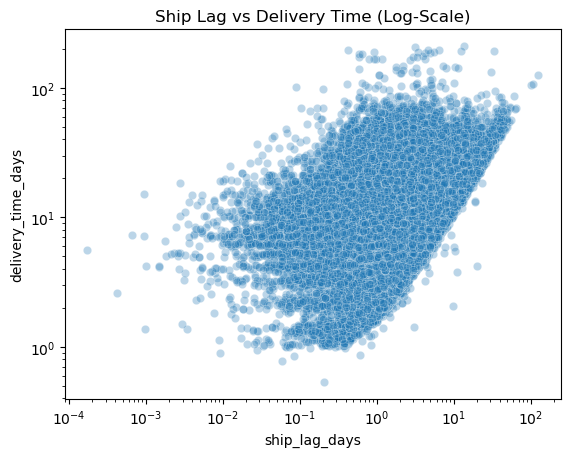

In [224]:
# Plot ship lag vs delivery time (log)
sns.scatterplot(
    x="ship_lag_days", 
    y="delivery_time_days", 
    data=df, 
    alpha=0.3
)
plt.xscale("log")
plt.yscale("log")
plt.title("Ship Lag vs Delivery Time (Log-Scale)")
plt.show()

##### Ship Lag vs Delivery Time Takeaways

- Ship lag is moderately correlated with total delivery time (corr ≈ 0.39).
- Most orders have ship lag under 5 days and total delivery under 15 days, reflecting a typical efficient process.
- Extreme outliers (very long ship lags) lead to extremely long delivery times and likely contribute to poor reviews.
- On a log–log scale the proportional relationship is clearer: longer ship lags translate directly into longer deliveries.
- Business insight: reducing ship lag times could have a direct impact on overall delivery performance and customer satisfaction.

## E. Multivariate Analysis

### i. Delivery Dynamics

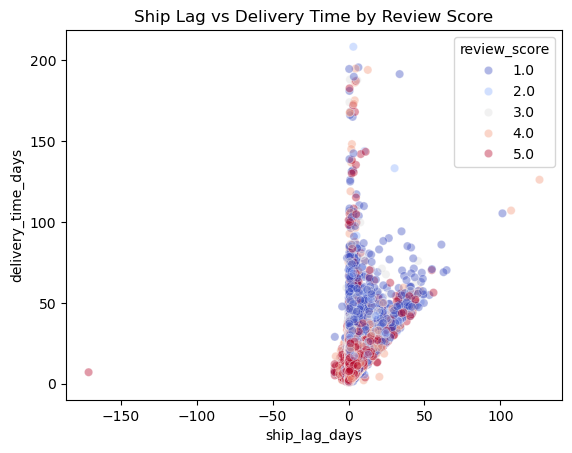

In [229]:
# Multivariate plot to explore shipping impact on review score
sns.scatterplot(
    x="ship_lag_days", 
    y="delivery_time_days", 
    hue="review_score", 
    palette="coolwarm", 
    data=df, 
    alpha=0.4
)
plt.title("Ship Lag vs Delivery Time by Review Score")
plt.show()

##### Delivery Dynamics Takeaways

- **Positive relationship**: Longer ship lags lead to longer overall delivery times (corr ≈ 0.39).  
- **Typical orders**: Most cluster around ship lag 0–5 days and delivery times of 5–20 days.  
- **Outliers**: A minority of orders have extreme ship lags (50+ days), pushing delivery times to 100+ days — often associated with poor reviews.  
- **Review score pattern**:  
  - High scores (4–5 stars) are concentrated in the bottom-left (short ship lag, short delivery times).  
  - Low scores (1–2 stars) appear more often at higher ship lags and delivery times.  
- **Business insight**: Shipping delays cascade into longer total delivery times and directly hurt customer satisfaction. Reducing ship lag could improve delivery reliability and boost review scores.

### ii. Order Complexity and Timeliness

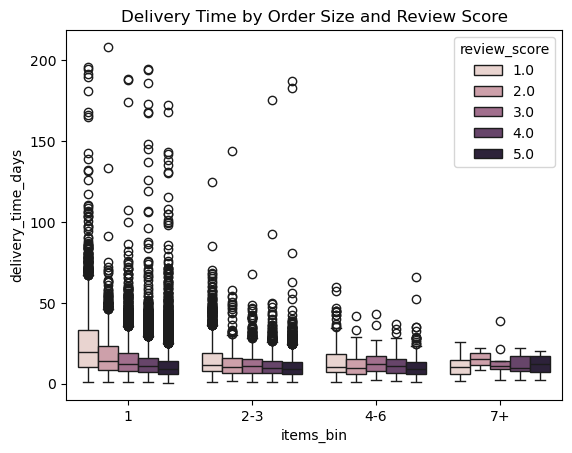

In [232]:
df['items_bin'] = pd.cut(df['items_n'], bins=[0,1,3,6,20], labels=["1","2-3","4-6","7+"])

sns.boxplot(x="items_bin", y="delivery_time_days", hue="review_score", data=df)
plt.title("Delivery Time by Order Size and Review Score")
plt.show()

##### Delivery Time by Order Size and Review Score Takeaways

- Across all order sizes, longer delivery times are strongly associated with lower review scores.  
- The effect of order size itself is minor.  A 7+ item order can still earn 5 stars if delivered quickly.  
- 1-star reviews consistently show extreme delivery times (50–200+ days), highlighting the risk of long-tail delays.  
- Business insight: customer satisfaction depends far more on delivery timeliness than on order size. Preventing very late deliveries should be the top priority.

### iii. Order Value, Installments and Satisfaction

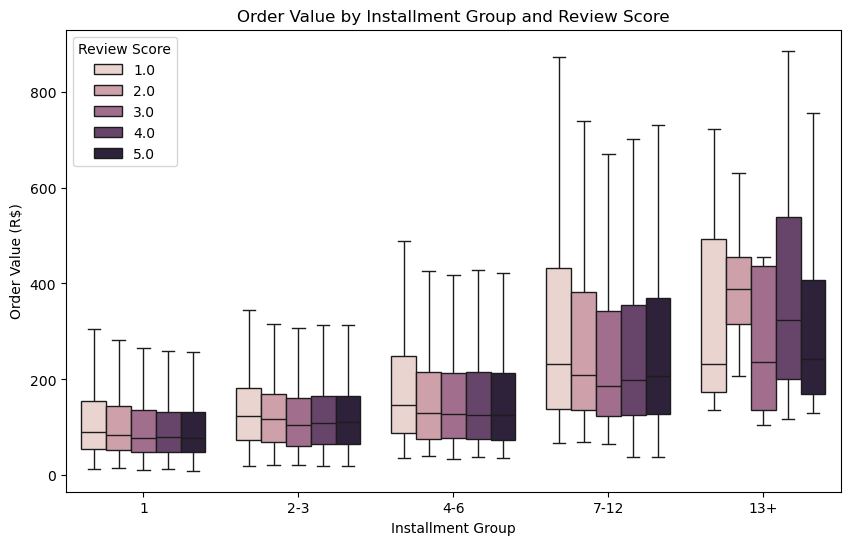

In [235]:
# Bin installments for readability
df['installment_bin'] = pd.cut(
    df['max_installments'],
    bins=[0,1,3,6,12,24],
    labels=["1","2-3","4-6","7-12","13+"]
)

# Plot order value, installments, and satisfaction
plt.figure(figsize=(10,6))
sns.boxplot(
    x="installment_bin", 
    y="order_value", 
    hue="review_score", 
    data=df,
    showfliers=False
)
plt.title("Order Value by Installment Group and Review Score")
plt.xlabel("Installment Group")
plt.ylabel("Order Value (R$)")
plt.legend(title="Review Score")
plt.show()

##### Order Value, Installments, and Review Score Takeaways

- Orders with higher installment counts (7–12, 13+) have much larger median values (300–500+), while 1–3 installment orders are typically ~100–150.  
- Within each installment group, review scores overlap heavily.  Payment structure does not strongly affect satisfaction.  
- Variance grows with installment count: large, high-value orders vary widely in value but customer ratings remain mixed.  
- Business insight: installment usage signals higher-value customers but does not predict review satisfaction. Delivery speed and reliability remain the dominant drivers of review score.

## F. Data Flow Diagram

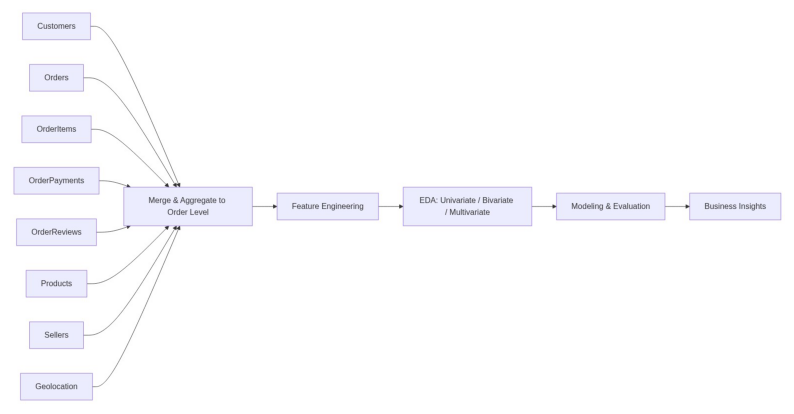

In [241]:
# Use mermaid.js to generate Data Flow Diagram

import base64, io, requests
from PIL import Image as PILImage

def render_mermaid(code: str, save_as: str | None = None):
    # Remove ```mermaid fences if present
    code = code.strip()
    if code.startswith("```mermaid"):
        code = code.replace("```mermaid", "", 1)
        # strip trailing backticks if they exist
        code = code.rstrip("`").strip()
    # Encode and fetch
    b64 = base64.urlsafe_b64encode(code.encode("utf-8")).decode("ascii")
    url = f"https://mermaid.ink/img/{b64}"
    resp = requests.get(url)
    resp.raise_for_status()
    img = PILImage.open(io.BytesIO(resp.content))
    # Show
    plt.figure(figsize=(10,6))
    plt.imshow(img)
    plt.axis('off')
    if save_as:
        img.save(save_as)
    plt.show()

mermaid_code = """
flowchart LR
    A[Customers] --> M[Merge & Aggregate to Order Level]
    B[Orders] --> M
    C[OrderItems] --> M
    D[OrderPayments] --> M
    E[OrderReviews] --> M
    F[Products] --> M
    G[Sellers] --> M
    H[Geolocation] --> M

    M --> FE[Feature Engineering]
    FE --> EDA[EDA: Univariate / Bivariate / Multivariate]
    EDA --> ME[Modeling & Evaluation]
    ME --> BI[Business Insights]
"""

render_mermaid(mermaid_code, save_as="data_flow_mermaid.png")

## G. Feature Selection

##### Feature Selection for Modeling
- Drop redundant variables: {order_price_sum, total_payment_value} (keep order_value).  
- Keep timeliness features: {ship_lag_days, delivery_time_days, delay_vs_est_days}.  
- Keep complexity features: {items_n, sellers_n, products_n}.  
- Payment features are weak predictors of satisfaction but may aid segmentation (keep max_installments).  
- Customer region (state) can help identify geographic differences.  

In [246]:
# Dropping redundant columns before feature engineering
df = df.drop(columns=[
    # IDs not needed for modeling
    'customer_id',
    'order_id',
])

In [248]:
# Drop redundant or less useful features
drop_cols = [
    # IDs not needed for modeling
    'customer_id',
    'order_id',
    
    # Redundant monetary features
    'total_payment_value', 
    'order_price_sum', 
    'order_freight_sum',
    
    # Redundant payment details (keep only the _any flags)
    'pay_boleto_n', 
    'pay_credit_card_n', 
    'pay_debit_card_n', 
    'pay_voucher_n', 
    'payments_count',
    
    # Redundant binned features
    'installment_bin', 
    'items_bin',
    
    # High-cardinality / less useful
    'customer_city',
]

df_clean = df.drop(columns=drop_cols, errors="ignore")

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Dropped columns:", [c for c in drop_cols if c in df.columns])

Original shape: (99441, 29)
Cleaned shape: (99441, 18)
Dropped columns: ['total_payment_value', 'order_price_sum', 'order_freight_sum', 'pay_boleto_n', 'pay_credit_card_n', 'pay_debit_card_n', 'pay_voucher_n', 'payments_count', 'installment_bin', 'items_bin', 'customer_city']


## H. Key Insights

##### Key Insights from EDA

- **Customer Concentration**: A large share of orders comes from a small group of repeat customers, while most customers purchase only once.  
- **Geographic Spread**: Customers are distributed across many Brazilian states, but major cities dominate in order volume.  
- **Order Timelines**: Delivery delays have a measurable impact on review scores, with late deliveries strongly linked to lower ratings.  
- **Product Categories**: A few product categories (e.g., bed, bath, table, health, beauty) drive most sales, while many categories have very low order counts.  
- **Price & Freight**: Prices and freight values are highly skewed, with a small number of very high-value orders/products distorting averages.  
- **Payment Behavior**: Most payments are made in installments, but the majority of orders are paid in fewer than three installments.  
- **Customer Satisfaction**: Average review scores are relatively high, but late deliveries and high freight costs correspond with negative reviews.  
- **RFM Analysis Potential**: Customers can be meaningfully segmented by frequency and recency, with clear opportunities for retention and targeting strategies.  

##### Key Features for Modeling

Based on the EDA, the following features are most relevant for predicting customer satisfaction (review score):

- **Delivery Delay**: Difference between estimated and actual delivery dates. Strongly correlated with lower review scores when delays occur.  
- **Order Value (Monetary)**: Total purchase value (items + freight). Larger orders may influence satisfaction differently than smaller ones.  
- **Payment Type and Installments**: Some payment methods and higher installment counts are associated with lower ratings, likely reflecting friction in the payment process.  
- **Freight Value**: Customers paying higher freight fees may be more sensitive to delivery performance.  
- **Recency, Frequency, and Monetary (RFM) Metrics**: Capture long-term customer behavior and help explain differences between one-time vs. loyal buyers.  

These features will form the basis of downstream regression models predicting review scores and clustering models for customer segmentation.

## I. Export DataFrame for Preprocessing

In [264]:
# Save to processed data folder
df.to_csv("../data/processed/olist_orders_eda_clean.csv", index=False)

## J. Appendix (Experimenting with Automated EDA)

In [256]:
# Testing Sweetfiz EDA

import sweetviz as sv

report = sv.analyze(df_clean)
report.show_html("sweetviz_report.html")

                                             |      | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [260]:
# Testing ydata-profiling

from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Profiling Report")
profile.to_file("ydata_profiling_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]